### Setup and library imports


In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU


### Dataset class definition


In [2]:
class FashionMNISTDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.labels = self.data.iloc[:, 0].values
        self.images = self.data.iloc[:, 1:].values.astype(np.uint8)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx].reshape(28, 28)
        img = Image.fromarray(img).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

### Image preprocessing and transforms


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Loading datasets from CSV files...")
full_train_dataset = FashionMNISTDataset("Data/fashion-mnist_train.csv", transform=train_transform)
test_dataset = FashionMNISTDataset("Data/fashion-mnist_test.csv", transform=val_transform)

train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

val_dataset = FashionMNISTDataset("Data/fashion-mnist_train.csv", transform=val_transform)
indices = list(range(len(full_train_dataset)))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_subset = Subset(full_train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

print(f"Training set size: {len(train_subset)}")
print(f"Validation set size: {len(val_subset)}")
print(f"Test set size: {len(test_dataset)}")

Loading datasets from CSV files...
Training set size: 54000
Validation set size: 6000
Test set size: 10000


### Visualizing sample dataset images


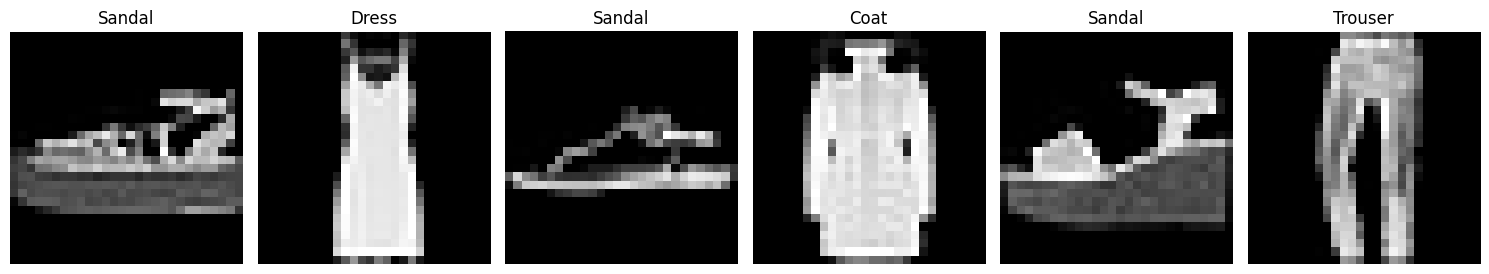

In [4]:
def show_samples(num_samples=6):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    plot_dataset = FashionMNISTDataset("Data/fashion-mnist_train.csv")
    for i in range(num_samples):
        idx = random.randint(0, len(plot_dataset) - 1)
        img = plot_dataset.images[idx].reshape(28, 28)
        lbl = plot_dataset.labels[idx]
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(class_names[lbl])
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

show_samples()

### Transfer learning model configuration


In [5]:
def get_model(model_name):
    if model_name == 'mobilenet_v2':
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
        for param in model.classifier[1].parameters():
            param.requires_grad = True
            
    elif model_name == 'mobilenet_v3_large':
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, 10)
        for param in model.classifier[3].parameters():
            param.requires_grad = True
            
    elif model_name == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, 10)
        for param in model.fc.parameters():
            param.requires_grad = True
    else:
        raise ValueError(f"Unknown model: {model_name}")
    return model

### Tuning search on training subset


In [6]:
tuning_train_size = 5000
tuning_val_size = 1000

tuning_train_indices = train_indices[:tuning_train_size]
tuning_val_indices = val_indices[:tuning_val_size]

tuning_train_subset = Subset(full_train_dataset, tuning_train_indices)
tuning_val_subset = Subset(val_dataset, tuning_val_indices)

tuning_train_loader = DataLoader(tuning_train_subset, batch_size=64, shuffle=True)
tuning_val_loader = DataLoader(tuning_val_subset, batch_size=64, shuffle=False)

configs = [
    {"name": "Model A: MobileNetV2 (lr=1e-3)", "model": "mobilenet_v2", "lr": 1e-3},
    {"name": "Model B: MobileNetV2 (lr=1e-4)", "model": "mobilenet_v2", "lr": 1e-4},
    {"name": "Model C: MobileNetV3-Large (lr=1e-3)", "model": "mobilenet_v3_large", "lr": 1e-3},
    {"name": "Model D: MobileNetV3-Large (lr=1e-4)", "model": "mobilenet_v3_large", "lr": 1e-4},
    {"name": "Model E: ResNet18 (lr=1e-3)", "model": "resnet18", "lr": 1e-3},
    {"name": "Model F: ResNet18 (lr=1e-4)", "model": "resnet18", "lr": 1e-4},
]

tuning_results = {}

for config in configs:
    name = config["name"]
    print(f"\nEvaluating {name}...")
    model = get_model(config["model"]).to(device)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=config["lr"])
    criterion = nn.CrossEntropyLoss()
    
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tuning_train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
        
    train_acc = correct / total
    
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tuning_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            val_total += labels.size(0)
            val_correct += preds.eq(labels).sum().item()
            
    val_acc = val_correct / val_total
    tuning_results[name] = {"val_acc": val_acc, "config": config}
    print(f"  Val Acc: {val_acc*100:.2f}%")


Evaluating Model A: MobileNetV2 (lr=1e-3)...
  Val Acc: 67.40%

Evaluating Model B: MobileNetV2 (lr=1e-4)...
  Val Acc: 39.20%

Evaluating Model C: MobileNetV3-Large (lr=1e-3)...
  Val Acc: 70.30%

Evaluating Model D: MobileNetV3-Large (lr=1e-4)...
  Val Acc: 29.20%

Evaluating Model E: ResNet18 (lr=1e-3)...
  Val Acc: 66.20%

Evaluating Model F: ResNet18 (lr=1e-4)...
  Val Acc: 24.70%


### Evaluating experimental search results


C:\Users\ARYAN SINGH JADAUN\AppData\Local\Temp\ipykernel_18628\2318115595.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_accs, y=names, palette="viridis")


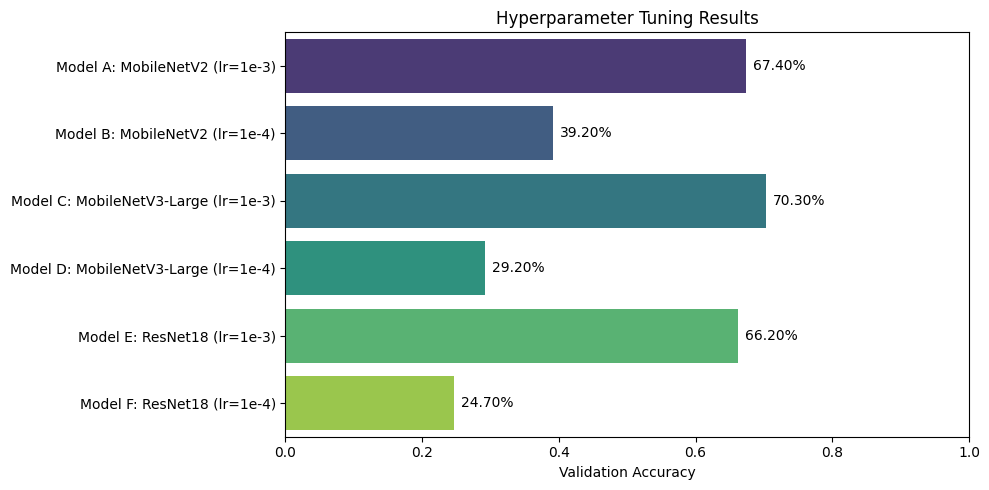

Best configuration: Model C: MobileNetV3-Large (lr=1e-3)


In [7]:
names = list(tuning_results.keys())
val_accs = [results["val_acc"] for results in tuning_results.values()]

plt.figure(figsize=(10, 5))
sns.barplot(x=val_accs, y=names, palette="viridis")
plt.title("Hyperparameter Tuning Results")
plt.xlabel("Validation Accuracy")
plt.xlim(0, 1.0)
for index, val in enumerate(val_accs):
    plt.text(val + 0.01, index, f"{val*100:.2f}%", va='center')
plt.tight_layout()
plt.show()

best_config_name = max(tuning_results, key=lambda k: tuning_results[k]["val_acc"])
best_config = tuning_results[best_config_name]["config"]
print(f"Best configuration: {best_config_name}")

### Training selected model on full dataset


In [8]:
full_train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
full_val_loader = DataLoader(val_subset, batch_size=128, shuffle=False)

print(f"Instantiating best model architecture: {best_config['model']}")
best_model = get_model(best_config["model"]).to(device)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, best_model.parameters()), lr=best_config["lr"])
criterion = nn.CrossEntropyLoss()

epochs = 5
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(epochs):
    best_model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in full_train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = best_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
        
    train_loss = running_loss / total
    train_acc = correct / total
    
    best_model.eval()
    running_val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in full_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = best_model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            val_total += labels.size(0)
            val_correct += preds.eq(labels).sum().item()
            
    val_loss = running_val_loss / val_total
    val_acc = val_correct / val_total
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc*100:.2f}%")

torch.save(best_model.state_dict(), "best_product_classifier.pth")
torch.save(best_model.state_dict(), "best_product_classifier.pkl")
print("Best model checkpoint saved to best_product_classifier.pth and best_product_classifier.pkl")

Instantiating best model architecture: mobilenet_v3_large
Epoch 1/5 | Train Loss: 0.8154 - Train Acc: 75.05% | Val Loss: 0.8636 - Val Acc: 70.90%
Epoch 2/5 | Train Loss: 0.5808 - Train Acc: 79.87% | Val Loss: 0.5463 - Val Acc: 81.05%
Epoch 3/5 | Train Loss: 0.5408 - Train Acc: 80.86% | Val Loss: 0.5176 - Val Acc: 82.07%
Epoch 4/5 | Train Loss: 0.5309 - Train Acc: 80.99% | Val Loss: 0.5032 - Val Acc: 82.28%
Epoch 5/5 | Train Loss: 0.5188 - Train Acc: 81.34% | Val Loss: 0.4893 - Val Acc: 82.87%
Best model checkpoint saved to best_product_classifier.pth and best_product_classifier.pkl


### Plotting training metrics and history


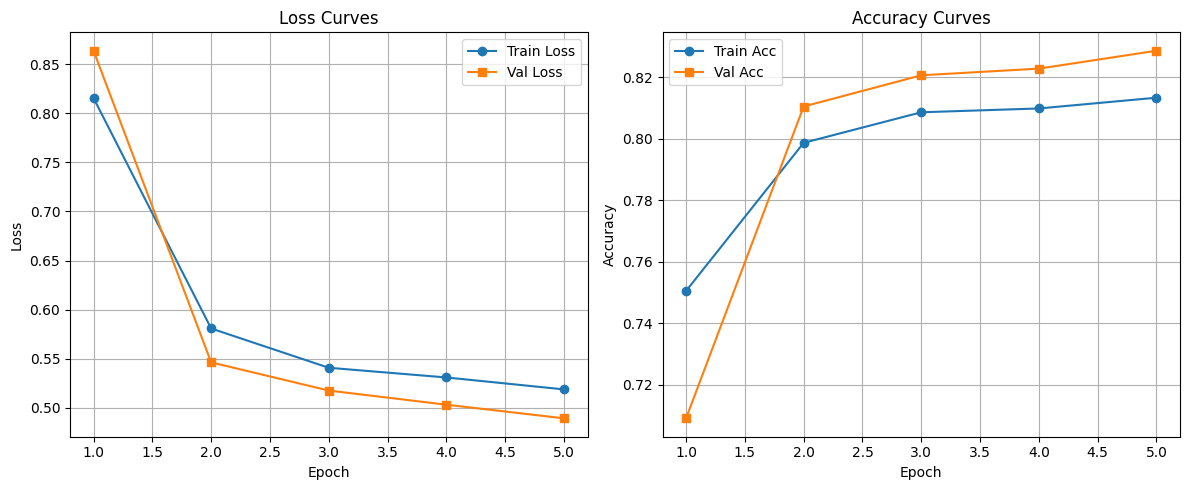

=== Diagnostic Report ===
Final Train Accuracy: 81.34%
Final Val Accuracy: 82.87%
Final Loss Difference: -0.0295
------------------------------
Diagnosis: WELL-FIT
Recommendation: Model is ready for deployment!


In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), history["train_loss"], label="Train Loss", marker='o')
plt.plot(range(1, epochs+1), history["val_loss"], label="Val Loss", marker='s')
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), history["train_acc"], label="Train Acc", marker='o')
plt.plot(range(1, epochs+1), history["val_acc"], label="Val Acc", marker='s')
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

final_train_loss = history["train_loss"][-1]
final_val_loss = history["val_loss"][-1]
final_train_acc = history["train_acc"][-1]
final_val_acc = history["val_acc"][-1]
loss_diff = final_val_loss - final_train_loss
acc_diff = final_train_acc - final_val_acc

print("=== Diagnostic Report ===")
print(f"Final Train Accuracy: {final_train_acc*100:.2f}%")
print(f"Final Val Accuracy: {final_val_acc*100:.2f}%")
print(f"Final Loss Difference: {loss_diff:.4f}")
print("-" * 30)
if final_train_acc < 0.75 or final_val_acc < 0.75:
    print("Diagnosis: UNDERFITTING")
    print("Recommendation: Train longer, unfreeze layers, or decrease regularization.")
elif loss_diff > 0.15 or acc_diff > 0.08:
    print("Diagnosis: OVERFITTING")
    print("Recommendation: Add data augmentation, dropout, or collect more samples.")
else:
    print("Diagnosis: WELL-FIT")
    print("Recommendation: Model is ready for deployment!")

### Evaluating model on testing set


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.73      0.78      1000
     Trouser       0.97      0.96      0.96      1000
    Pullover       0.82      0.73      0.77      1000
       Dress       0.78      0.88      0.83      1000
        Coat       0.75      0.71      0.73      1000
      Sandal       0.93      0.90      0.92      1000
       Shirt       0.57      0.66      0.61      1000
     Sneaker       0.88      0.90      0.89      1000
         Bag       0.93      0.95      0.94      1000
  Ankle boot       0.92      0.92      0.92      1000

    accuracy                           0.83     10000
   macro avg       0.84      0.83      0.84     10000
weighted avg       0.84      0.83      0.84     10000



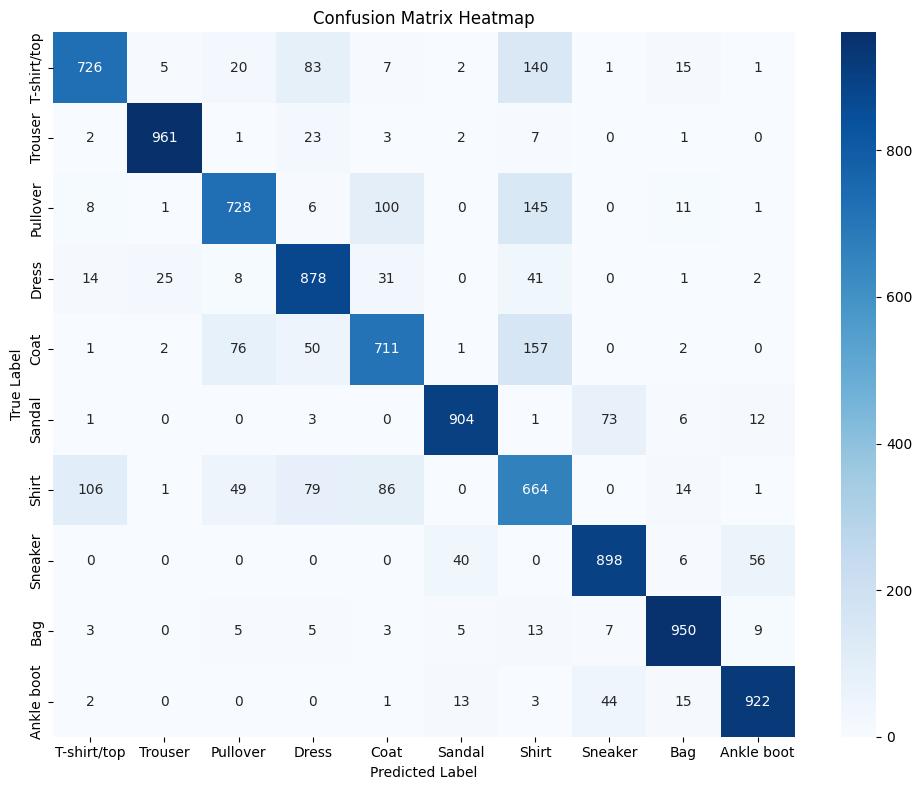

In [10]:
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
best_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = best_model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Prediction test helper function


C:\Users\ARYAN SINGH JADAUN\AppData\Local\Temp\ipykernel_18628\3255812037.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  true_label = row[0]


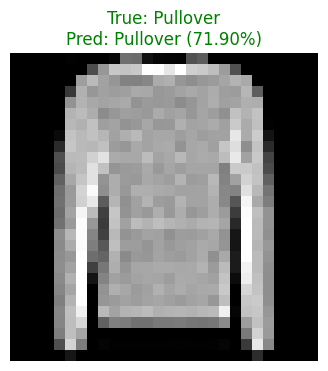

In [11]:
def predict_random_image():
    test_df = pd.read_csv("Data/fashion-mnist_test.csv")
    idx = random.randint(0, len(test_df) - 1)
    row = test_df.iloc[idx]
    true_label = row[0]
    pixels = row[1:].values.astype(np.uint8).reshape(28, 28)
    
    pil_img = Image.fromarray(pixels).convert('RGB')
    input_tensor = val_transform(pil_img).unsqueeze(0).to(device)
    
    best_model.eval()
    with torch.no_grad():
        outputs = best_model(input_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        conf, pred_label = torch.max(probs, dim=0)
        
    true_class = class_names[true_label]
    pred_class = class_names[pred_label.item()]
    
    plt.figure(figsize=(4, 4))
    plt.imshow(pixels, cmap='gray')
    plt.title(f"True: {true_class}\nPred: {pred_class} ({conf.item()*100:.2f}%)",
              color='green' if true_label == pred_label.item() else 'red')
    plt.axis('off')
    plt.show()

predict_random_image()